# QP Trace Simulation Tutorial

This notebook walks through three things:

1. **Generating clean (noise-free) QP traces** with `QPSimulator` &mdash; the minimal standalone simulator that mirrors the QP/phonon path of `TraceSimulator` exactly.
2. **Using the `NoiseGenerator`** that ships with the project to draw colored Gaussian noise.
3. **Putting them together** &mdash; adding noise on top of a clean QP trace.

Prerequisites: `numpy`, `scipy`, `matplotlib`. The notebook expects to be run from the package root (`TraceSimulator/`).

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# allow `from QPSimulator import QPSimulator` and `from NoiseGenerator import NoiseGenerator`
sys.path.insert(0, os.getcwd())

from QPSimulator import QPSimulator
# Import NoiseGenerator without triggering the full package __init__ (which pulls h5py etc.)
from noise_module.NoiseGenerator import NoiseGenerator

rng = np.random.default_rng(0)

## 1. Clean QP traces with `QPSimulator`

The simulator builds a single-QP calorimetric response template &mdash; an exponential rise (τ_rise) followed by an exponential decay (τ_decay), peaking at `trigger_time` &mdash; and sums one copy per supplied arrival time.

Defaults match `TraceSimulator`: `f_s = 2.5×10⁵ Hz`, `trace_samples = 16384`, `τ_rise = 50 µs`, `τ_decay = 3 ms`, `trigger_time = 10% of the trace`.

Per-QP ADC amplitude:

$$A_\text{QP} = \text{gain}_\text{QE}\;\cdot\;E_\text{ADC}\;\cdot\;10^{-3}\;\cdot\;\text{meV}_\text{per QP}$$

(the $10^{-3}$ converts the $\sim$1 meV per phonon to eV).

In [2]:
sim = QPSimulator()
print(f"dt              = {sim.dt:g} ns")
print(f"trace duration  = {sim.trace_duration*1e-6:.2f} ms ({sim.trace_samples} samples)")
print(f"trigger_time    = {sim.trigger_time*1e-6:.2f} ms")
print(f"τ_rise / τ_decay = {sim.tau_rise*1e-3:g} µs / {sim.tau_decay*1e-6:g} ms")
print(f"per-QP amplitude= {sim.qp_amplitude:.4g} ADC counts")

t_ms = np.arange(sim.trace_samples) * sim.dt * 1e-6   # time axis in ms

dt              = 4000 ns
trace duration  = 65.54 ms (16384 samples)
trigger_time    = 6.55 ms
τ_rise / τ_decay = 50 µs / 3 ms
per-QP amplitude= 0.03 ADC counts


### 1.1 Single QP arriving at t = 0

A QP arriving at `t = 0` produces a peak at `trigger_time`. The peak height equals `qp_amplitude` (modulo discretization).

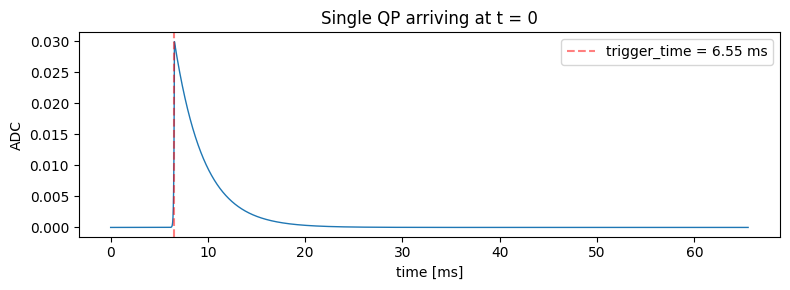

In [3]:
trace = sim.generate([0.0])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms, trace, lw=1)
ax.axvline(sim.trigger_time*1e-6, color='r', ls='--', alpha=0.5, label=f'trigger_time = {sim.trigger_time*1e-6:.2f} ms')
ax.set_xlabel("time [ms]"); ax.set_ylabel("ADC")
ax.set_title("Single QP arriving at t = 0"); ax.legend()
fig.tight_layout()

### 1.2 Many QPs sampled from an arrival-time distribution

Real events have many QPs arriving at slightly different times because of ballistic propagation (≈1505–200 m/s in superfluid He-4). Whatever distribution you have for the arrival times — from a detector simulation, an analytic model, or a hand-picked function — just hand it to `generate(arrival_times)`.

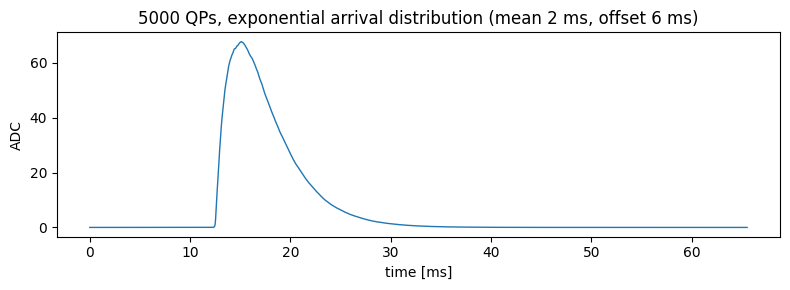

In [4]:
N_QP = 5_000
t_arr = rng.exponential(scale=2e6, size=N_QP) + 6e6   # ns; 2 ms tail starting at 6 ms
trace = sim.generate(t_arr)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms, trace, lw=1)
ax.set_xlabel("time [ms]"); ax.set_ylabel("ADC")
ax.set_title(f"{N_QP} QPs, exponential arrival distribution (mean 2 ms, offset 6 ms)")
fig.tight_layout()

### 1.3 Different arrival-time scenarios produce different pulse shapes

This is the "shift-manifold" sandbox &mdash; same QP count, varying arrival-time distribution. Notice both the peak position *and* the pulse shape change.

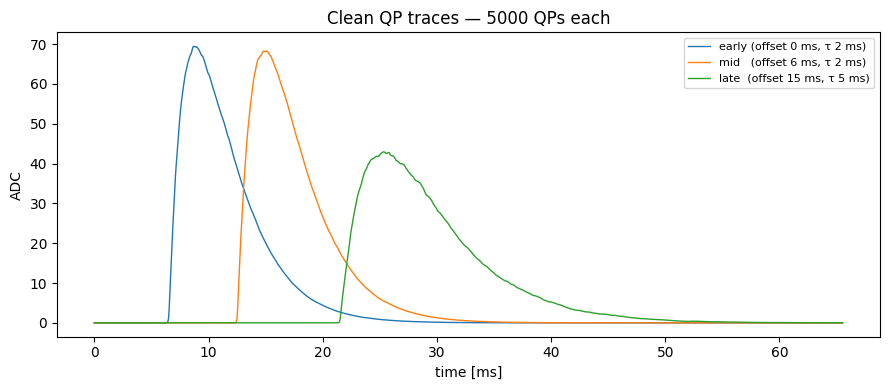

In [5]:
scenarios = {
    "early (offset 0 ms, τ 2 ms)":   rng.exponential(2e6, N_QP) + 0.0,
    "mid   (offset 6 ms, τ 2 ms)":   rng.exponential(2e6, N_QP) + 6e6,
    "late  (offset 15 ms, τ 5 ms)":  rng.exponential(5e6, N_QP) + 15e6,
}

fig, ax = plt.subplots(figsize=(9, 4))
for label, t in scenarios.items():
    ax.plot(t_ms, sim.generate(t), lw=1.0, label=label)
ax.set_xlabel("time [ms]"); ax.set_ylabel("ADC")
ax.set_title(f"Clean QP traces — {N_QP} QPs each"); ax.legend(fontsize=8)
fig.tight_layout()

## 2. The `NoiseGenerator`

`NoiseGenerator` produces a 1D array of colored Gaussian-like noise of length `N`. The constructor needs three keys in its config dict:

| key | meaning |
|---|---|
| `noise_type` | one of `'white' / 'pink' / 'blue' / 'violet' / 'brownian'`, **or** a path to a custom `.npy` PSD file |
| `noise_power` | the time-domain *variance*. So `std = sqrt(noise_power)` |
| `sampling_frequency` | Hz |

Spectral slopes (verified empirically): white = 0, pink = −1, blue = +1, violet = +2, brownian = −2.

In [6]:
cfg = dict(noise_type='pink', noise_power=25.0, sampling_frequency=2.5e5)
ng = NoiseGenerator(cfg)
noise = ng.generate_noise(sim.trace_samples)

print(f"noise_power    = {cfg['noise_power']}")
print(f"empirical std  = {noise.std():.3f}   (≈ sqrt(noise_power) = {np.sqrt(cfg['noise_power']):.3f})")
print(f"empirical mean = {noise.mean():+.4f}")

noise_power    = 25.0
empirical std  = 5.158   (≈ sqrt(noise_power) = 5.000)
empirical mean = -0.0000


### 2.1 Visualizing the five colors

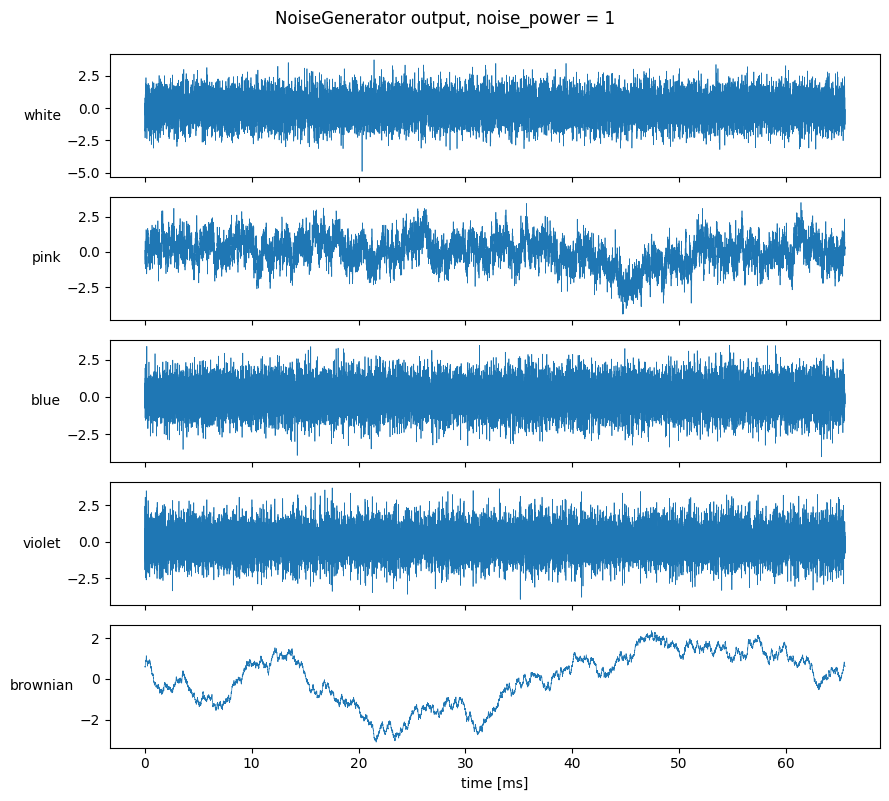

In [7]:
colors = ['white', 'pink', 'blue', 'violet', 'brownian']
fig, axes = plt.subplots(len(colors), 1, figsize=(9, 8), sharex=True)
for ax, c in zip(axes, colors):
    ng = NoiseGenerator(dict(noise_type=c, noise_power=1.0, sampling_frequency=2.5e5))
    n = ng.generate_noise(sim.trace_samples)
    ax.plot(t_ms, n, lw=0.5)
    ax.set_ylabel(c, rotation=0, ha='right', va='center')
axes[-1].set_xlabel("time [ms]")
fig.suptitle("NoiseGenerator output, noise_power = 1", y=0.995)
fig.tight_layout()

### 2.2 Verifying the PSD slopes

Average the periodogram over many traces and fit `log PSD` vs `log f`. Slopes should be (white, pink, blue, violet, brownian) = (0, −1, +1, +2, −2).

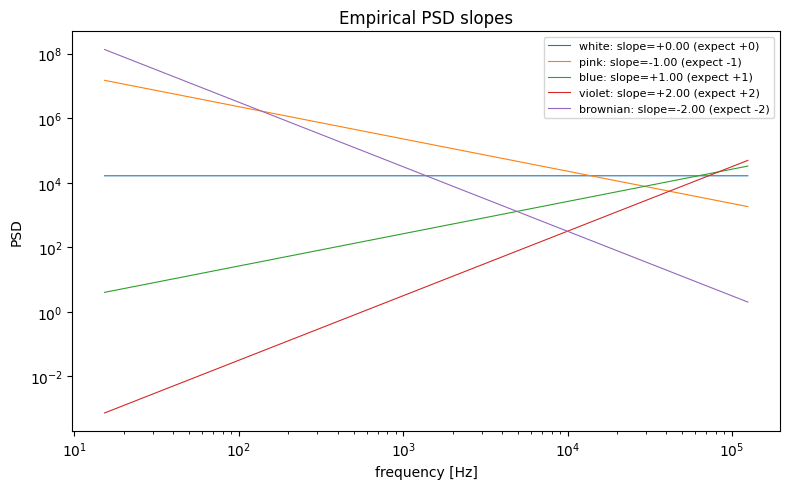

In [8]:
fs = sim.frequency
N  = sim.trace_samples
freq = np.fft.rfftfreq(N, d=1/fs)
mid = (freq > 5) & (freq < 5e4)

fig, ax = plt.subplots(figsize=(8, 5))
for c, expected in [('white', 0), ('pink', -1), ('blue', +1), ('violet', +2), ('brownian', -2)]:
    ng = NoiseGenerator(dict(noise_type=c, noise_power=1.0, sampling_frequency=fs))
    samples = np.stack([ng.generate_noise(N) for _ in range(50)])
    psd = (np.abs(np.fft.rfft(samples, axis=1))**2).mean(axis=0)
    slope, _ = np.polyfit(np.log(freq[mid]), np.log(psd[mid]), 1)
    ax.loglog(freq[1:], psd[1:], lw=0.8, label=f"{c}: slope={slope:+.2f} (expect {expected:+d})")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("PSD"); ax.legend(fontsize=8); ax.set_title("Empirical PSD slopes")
fig.tight_layout()

## 3. Putting it together: noisy QP traces

Generate a clean QP trace, draw a noise realization with the same length, sum them. Quantize to integer ADC counts if you want to match the digitizer.

In [9]:
# ---- 1. clean QP trace -------------------------------------------------
N_QP  = 5_000
t_arr = rng.exponential(scale=2e6, size=N_QP) + 6e6     # ns
clean = sim.generate(t_arr)

# ---- 2. noise realization ---------------------------------------------
ng    = NoiseGenerator(dict(noise_type='pink', noise_power=10.0, sampling_frequency=sim.frequency))
noise = ng.generate_noise(sim.trace_samples)

# ---- 3. combine --------------------------------------------------------
noisy = clean + noise
noisy_int = noisy.astype(int)   # if you want integer ADC, like TraceSimulator

# diagnostics
snr = clean.max() / noise.std()
print(f"clean peak  : {clean.max():7.2f} ADC")
print(f"noise std   : {noise.std():7.2f} ADC")
print(f"peak / std  : {snr:7.2f}   (rough single-sample SNR)")

clean peak  :   67.77 ADC
noise std   :    3.26 ADC
peak / std  :   20.78   (rough single-sample SNR)


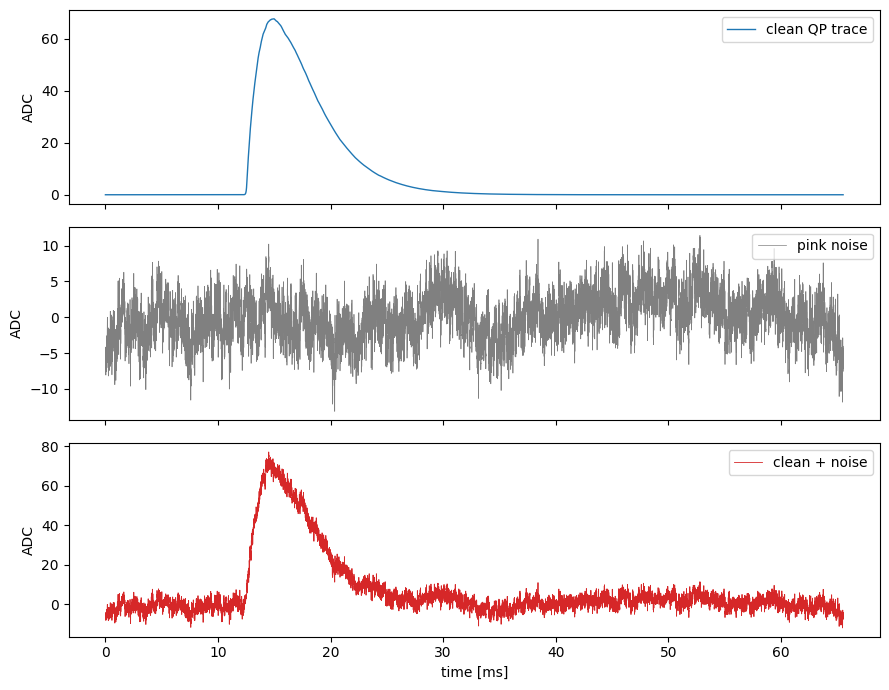

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_ms, clean, lw=1.0, color='C0', label='clean QP trace')
axes[1].plot(t_ms, noise, lw=0.5, color='gray', label='pink noise')
axes[2].plot(t_ms, noisy, lw=0.6, color='C3', label='clean + noise')
for ax in axes:
    ax.legend(loc='upper right'); ax.set_ylabel('ADC')
axes[-1].set_xlabel('time [ms]')
fig.tight_layout()

### 3.1 Sweeping noise level vs SNR

Same clean trace, varying `noise_power`.

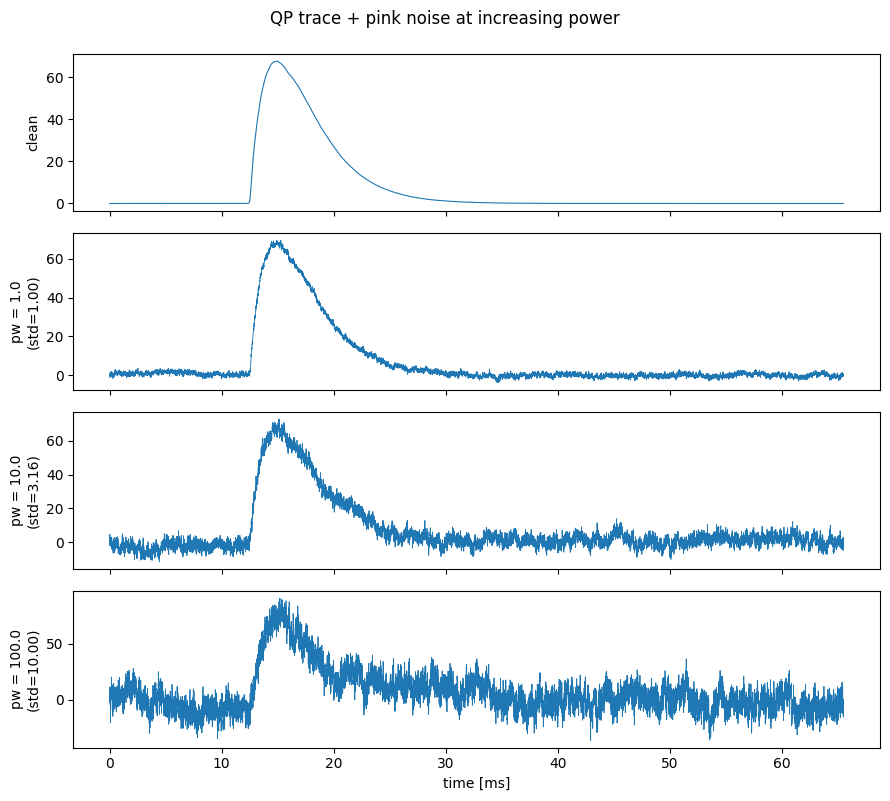

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, pw in zip(axes, [0.0, 1.0, 10.0, 100.0]):
    if pw == 0.0:
        ax.plot(t_ms, clean, lw=0.8, color='C0')
        ax.set_ylabel('clean')
    else:
        ng = NoiseGenerator(dict(noise_type='pink', noise_power=pw, sampling_frequency=sim.frequency))
        ax.plot(t_ms, clean + ng.generate_noise(sim.trace_samples), lw=0.6)
        ax.set_ylabel(f'pw = {pw}\n(std={np.sqrt(pw):.2f})')
axes[-1].set_xlabel('time [ms]')
fig.suptitle('QP trace + pink noise at increasing power', y=0.995)
fig.tight_layout()

### 3.2 Generating an ensemble of (clean, noisy) pairs

Convenient pattern for training/evaluation datasets: pair each clean trace with an independent noise draw.

clean_ds shape: (20, 16384)
noisy_ds shape: (20, 16384)


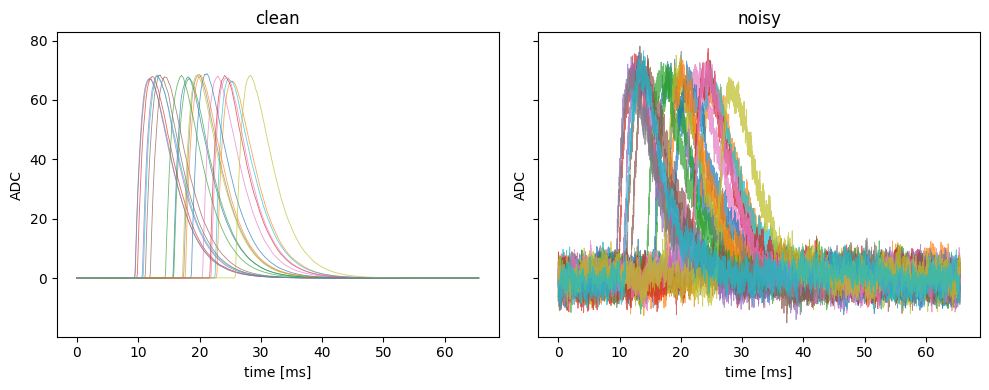

In [12]:
n_events  = 20
ng        = NoiseGenerator(dict(noise_type='pink', noise_power=10.0, sampling_frequency=sim.frequency))

clean_ds  = np.empty((n_events, sim.trace_samples))
noisy_ds  = np.empty((n_events, sim.trace_samples))
offsets   = rng.uniform(2e6, 20e6, n_events)   # different per-event arrival-time offsets (ns)

for k in range(n_events):
    t_arr        = rng.exponential(scale=2e6, size=N_QP) + offsets[k]
    clean_ds[k]  = sim.generate(t_arr)
    noisy_ds[k]  = clean_ds[k] + ng.generate_noise(sim.trace_samples)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(t_ms, clean_ds.T, lw=0.6, alpha=0.7); axes[0].set_title('clean')
axes[1].plot(t_ms, noisy_ds.T, lw=0.6, alpha=0.7); axes[1].set_title('noisy')
for ax in axes:
    ax.set_xlabel('time [ms]'); ax.set_ylabel('ADC')
fig.tight_layout()
print(f"clean_ds shape: {clean_ds.shape}")
print(f"noisy_ds shape: {noisy_ds.shape}")

## 4. New API: batch generation, shifted templates, and PSD estimation

This section covers four additions to `QPSimulator` that support the
paper's experiment suite:

| Method | Purpose |
|---|---|
| `generate(…, return_amplitude=True)` | Ground-truth amplitude alongside a single trace |
| `generate_family(…)` | Batch of N traces with per-event parameter variation and ground-truth dict |
| `get_template_at_shift(t0_shift_ns)` | Shifted single-QP template for time-shift optimal filtering |
| `estimate_psd(noise_traces, fs)` | One-sided PSD from noise-only traces (static method) |


### 4.1 `return_amplitude=True` — ground-truth amplitude for a single event

When you need to compare an estimator's output against the true signal
amplitude without calling `generate_family`, pass `return_amplitude=True`.
The second return value is `n_inside × qp_amplitude`, where `n_inside` is
the number of arrival times that fell inside `[0, trace_duration)`.

In [13]:
arrivals = rng.exponential(scale=2e6, size=5_000) + sim.trigger_time

# Original behaviour — unchanged
trace_only = sim.generate(arrivals)

# New: get trace AND ground-truth amplitude in one call
trace, amp_true = sim.generate(arrivals, return_amplitude=True)

print(f'trace shape  : {trace.shape}')
print(f'amp_true     : {amp_true:.4f} ADC  ')
print(f'expected ≈   : {5000 * sim.qp_amplitude:.4f} ADC  (5000 × {sim.qp_amplitude:.4f})')
print(f'backward-compat check: arrays identical = {np.allclose(trace, trace_only)}')

trace shape  : (16384,)
amp_true     : 150.0000 ADC  
expected ≈   : 150.0000 ADC  (5000 × 0.0300)
backward-compat check: arrays identical = True


### 4.2 `generate_family()` — batch generation with per-event variation

`generate_family()` returns:

- **`traces`** — `np.ndarray` of shape `(n_events, trace_samples)`, clean (no noise)
- **`params`** — dict with keys `tau_decay`, `t0_shift`, `n_QP`, `amplitude_ADC`

Per-event `tau_decay`, arrival-time jitter, and QP count are each drawn
independently from the specified ranges. Pass `(x, x)` for a fixed value.

The design follows the existing QPSimulator convention: **noise is not added here**.
Apply it externally using `NoiseGenerator` or `MultiChannelNoiseGenerator`
so the same clean family can be reused across different noise experiments.

In [14]:
traces, params = sim.generate_family(
    n_events       = 200,
    tau_decay_range = (2e6, 4e6),     # ns: vary decay time ±33%
    t0_jitter_range = (-5e4, 5e4),    # ns: ±50 µs trigger jitter
    n_QP_range      = (2000, 8000),   # vary signal energy
    rng             = rng,
)

print(f'traces shape     : {traces.shape}')
print(f'tau_decay range  : [{params["tau_decay"].min()*1e-6:.2f}, {params["tau_decay"].max()*1e-6:.2f}] ms')
print(f't0_shift range   : [{params["t0_shift"].min()*1e-3:.0f}, {params["t0_shift"].max()*1e-3:.0f}] µs')
print(f'n_QP range       : [{params["n_QP"].min()}, {params["n_QP"].max()}]')
print(f'amplitude range  : [{params["amplitude_ADC"].min():.2f}, {params["amplitude_ADC"].max():.2f}] ADC')

traces shape     : (200, 16384)
tau_decay range  : [2.00, 3.99] ms
t0_shift range   : [-49, 49] µs
n_QP range       : [2003, 7995]
amplitude range  : [60.09, 239.85] ADC


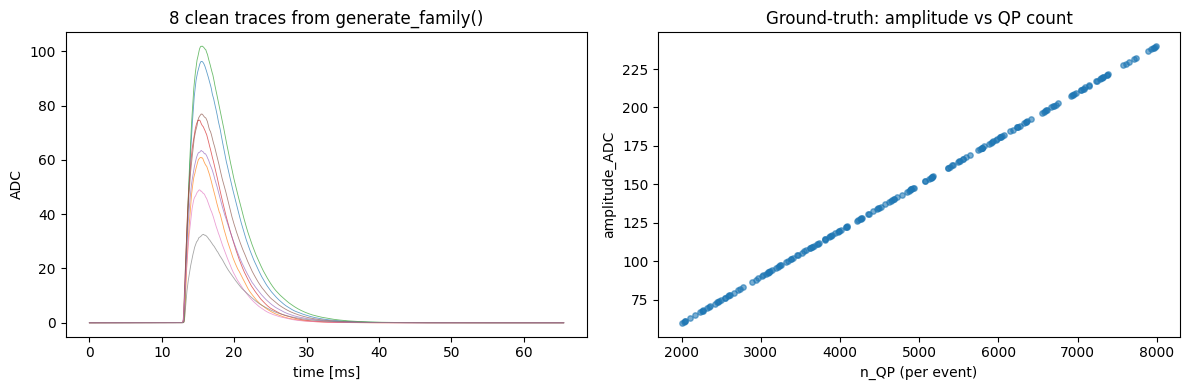

In [15]:
# Visualize: first 8 clean traces and amplitude vs n_QP scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i in range(8):
    axes[0].plot(t_ms, traces[i], lw=0.6, alpha=0.7)
axes[0].set_xlabel('time [ms]'); axes[0].set_ylabel('ADC')
axes[0].set_title('8 clean traces from generate_family()')

axes[1].scatter(params['n_QP'], params['amplitude_ADC'], s=15, alpha=0.6)
axes[1].set_xlabel('n_QP (per event)'); axes[1].set_ylabel('amplitude_ADC')
axes[1].set_title('Ground-truth: amplitude vs QP count')

fig.tight_layout()

#### 4.2.1 The standard experiment pipeline

```
generate_family()   →   add noise externally   →   estimate_psd()   →   run estimator   →   compare to params
```

The cell below demonstrates this end-to-end for a simple amplitude-recovery check.

In [16]:
# 1. Clean family
traces_clean, params = sim.generate_family(
    n_events=500, n_QP_range=(4000, 6000), rng=rng
)

# 2. Add pink noise to every event
ng = NoiseGenerator(dict(noise_type='pink', noise_power=5.0,
                         sampling_frequency=sim.frequency))
traces_noisy = traces_clean + np.stack(
    [ng.generate_noise(sim.trace_samples) for _ in range(500)]
)

# 3. Estimate PSD from 200 dedicated noise-only traces
noise_only = np.stack([ng.generate_noise(sim.trace_samples) for _ in range(200)])
freqs, Jk = QPSimulator.estimate_psd(noise_only, sim.frequency)

# 4. Toy amplitude estimator: project each noisy trace onto the template
#    using the noise-weighted inner product  Â = (s†Σ⁻¹x) / (s†Σ⁻¹s)
s = sim.template[:sim.trace_samples]          # nominal template (not scaled)
S = np.fft.rfft(s)
Jk_safe = np.maximum(Jk, 1e-30)               # ridge floor
of_kernel = S.conj() / Jk_safe

A_hat = np.array([
    np.real(np.dot(of_kernel, np.fft.rfft(x))) /
    np.real(np.dot(of_kernel, S))
    for x in traces_noisy
])

A_true = params['amplitude_ADC']
residuals = A_hat - A_true
print(f'bias  : {residuals.mean():+.4f} ADC')
print(f'std   : {residuals.std():.4f} ADC')
print(f'|bias|/std: {abs(residuals.mean())/residuals.std():.3f}  (should be ≪ 1 for unbiased estimator)')

bias  : -0.0000 ADC
std   : 0.0000 ADC
|bias|/std: 4.642  (should be ≪ 1 for unbiased estimator)


### 4.3 `get_template_at_shift()` — shifted templates for time-shift optimal filtering

For the time-shift optimal-filtering experiment (E8 in the paper checklist),
you need to build a filter kernel at each candidate time offset.
`get_template_at_shift(t0_shift_ns)` returns the single-QP template
shifted by `t0_shift_ns` nanoseconds relative to `self.trigger_time`,
truncated to `trace_samples`.

The returned array is the **unnormalised template** (peak ≈ 1), not scaled
by `qp_amplitude` — multiply by `qp_amplitude` if you need ADC units.

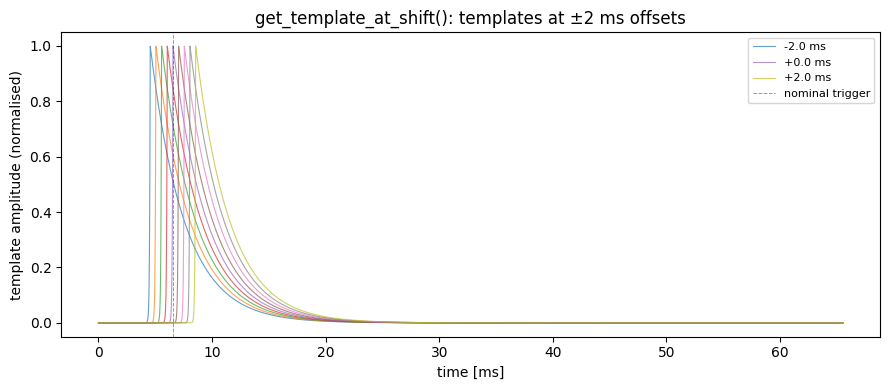

In [17]:
shifts_ms = np.linspace(-2, 2, 9)   # ±2 ms in steps of 0.5 ms

fig, ax = plt.subplots(figsize=(9, 4))
for ds in shifts_ms:
    tmpl = sim.get_template_at_shift(ds * 1e6)   # convert ms → ns
    ax.plot(t_ms, tmpl, lw=0.8, alpha=0.7, label=f'{ds:+.1f} ms' if abs(ds) in (0, 2) else '')

ax.axvline(sim.trigger_time * 1e-6, color='k', ls='--', lw=0.7, alpha=0.4, label='nominal trigger')
ax.set_xlabel('time [ms]'); ax.set_ylabel('template amplitude (normalised)')
ax.set_title('get_template_at_shift(): templates at ±2 ms offsets')
ax.legend(fontsize=8)
fig.tight_layout()

In [18]:
# Verify: peak shifts by exactly the requested number of samples
for ds_ms in [-1.0, 0.0, 0.5, 1.0]:
    tmpl = sim.get_template_at_shift(ds_ms * 1e6)
    peak_sample = np.argmax(tmpl)
    expected    = int(round((sim.trigger_time + ds_ms * 1e6) / sim.dt))
    print(f'shift {ds_ms:+.1f} ms → peak at sample {peak_sample:5d}  (expected {expected:5d})')

shift -1.0 ms → peak at sample  1389  (expected  1388)
shift +0.0 ms → peak at sample  1639  (expected  1638)
shift +0.5 ms → peak at sample  1764  (expected  1763)
shift +1.0 ms → peak at sample  1889  (expected  1888)


### 4.4 `estimate_psd()` — one-sided PSD from noise-only traces

`QPSimulator.estimate_psd(noise_traces, sampling_frequency)` is a static
method that computes the averaged periodogram across a `(N_traces, trace_samples)`
array of noise-only traces and returns the one-sided PSD `J_k` (ADC²/Hz).

**Normalisation:** `J_k = mean(|FFT(x)|²) × 2 / (N × f_s)`

so that `sum(J_k) × (f_s / N) ≈ noise_power` — the same convention used
internally by `NoiseGenerator`.

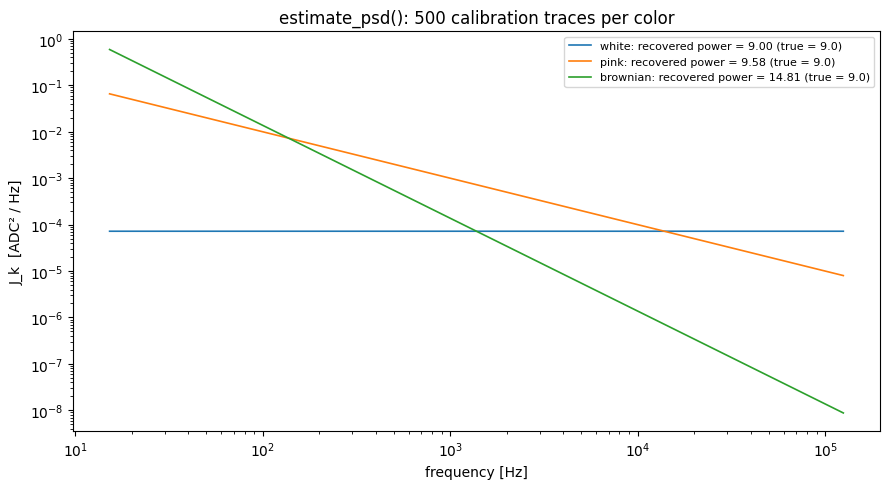

In [19]:
# Generate 500 noise-only traces at known power for each color
known_power = 9.0   # ADC²
N_cal = 500

fig, ax = plt.subplots(figsize=(9, 5))
for color in ['white', 'pink', 'brownian']:
    ng_cal = NoiseGenerator(dict(noise_type=color, noise_power=known_power,
                                  sampling_frequency=sim.frequency))
    cal_traces = np.stack([ng_cal.generate_noise(sim.trace_samples) for _ in range(N_cal)])
    freqs_est, Jk_est = QPSimulator.estimate_psd(cal_traces, sim.frequency)

    # Recovered power = integral of one-sided PSD over positive frequencies
    recovered = Jk_est.sum() * (sim.frequency / sim.trace_samples)
    ax.loglog(freqs_est[1:], Jk_est[1:], lw=1.2,
              label=f'{color}: recovered power = {recovered:.2f} (true = {known_power})')

ax.set_xlabel('frequency [Hz]'); ax.set_ylabel('J_k  [ADC² / Hz]')
ax.set_title(f'estimate_psd(): {N_cal} calibration traces per color')
ax.legend(fontsize=8)
fig.tight_layout()

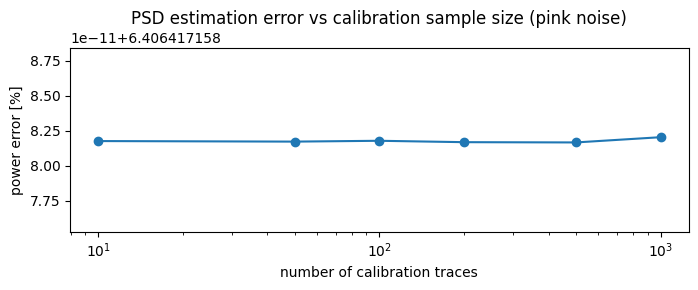

In [20]:
# Quantify estimation error vs number of calibration traces
ng_pink = NoiseGenerator(dict(noise_type='pink', noise_power=known_power,
                               sampling_frequency=sim.frequency))
n_cal_sweep = [10, 50, 100, 200, 500, 1000]
errors = []
for n_cal in n_cal_sweep:
    cal = np.stack([ng_pink.generate_noise(sim.trace_samples) for _ in range(n_cal)])
    _, Jk_est = QPSimulator.estimate_psd(cal, sim.frequency)
    recovered = Jk_est.sum() * (sim.frequency / sim.trace_samples)
    errors.append(abs(recovered - known_power) / known_power * 100)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(n_cal_sweep, errors, 'o-')
ax.set_xlabel('number of calibration traces'); ax.set_ylabel('power error [%]')
ax.set_title('PSD estimation error vs calibration sample size (pink noise)')
ax.set_xscale('log')
fig.tight_layout()

## Recap

**Core API**

- **`QPSimulator(...)`** — build once with your digitizer/template parameters.
- **`sim.generate(arrival_times_ns)`** — clean trace, shape `(trace_samples,)`.
- **`sim.generate(arrival_times_ns, return_amplitude=True)`** — `(trace, amp_true)`, where `amp_true = n_inside × qp_amplitude`.

**Batch / experiment API** *(new)*

- **`sim.generate_family(n_events, tau_decay_range, t0_jitter_range, n_QP_range, rng)`**
  — `(traces, params)` where `traces` is `(N, trace_samples)` and `params` is a dict with `tau_decay`, `t0_shift`, `n_QP`, `amplitude_ADC` — all per-event ground truth. No noise added; apply externally.
- **`sim.get_template_at_shift(t0_shift_ns)`** — single-QP template shifted by `t0_shift_ns` ns from `trigger_time`. Use to build time-shift OF filter banks.
- **`QPSimulator.estimate_psd(noise_traces, fs)`** — static method; averaged periodogram from `(N_traces, trace_samples)` noise-only array. Returns `(freqs, J_k)`.

**Standard experiment pipeline**

```python
# 1. Clean family with ground truth
traces_clean, params = sim.generate_family(n_events=500, n_QP_range=(3000, 7000), rng=rng)
# 2. Add noise externally
traces_noisy = traces_clean + np.stack([ng.generate_noise(sim.trace_samples) for _ in range(500)])
# 3. PSD from dedicated noise-only calibration traces
freqs, Jk = QPSimulator.estimate_psd(noise_cal_traces, sim.frequency)
# 4. Run estimator → compare output to params['amplitude_ADC']
```

**Noise module** (unchanged)

- **`NoiseGenerator({'noise_type': 'pink', 'noise_power': σ², 'sampling_frequency': f_s})`** — `ng.generate_noise(N)` returns an independent realization each call.
- **`MultiChannelNoiseGenerator`** — correlated multi-channel noise.
- **`ArtifactInjector`** and **`TemporalNoiseWrapper`** — glitches, drift, piecewise-stationary effects.

The clean-trace path is bit-equivalent (to one float64 ulp) with the QP/phonon path of the full `TraceSimulator`.